In [4]:
import json

In [5]:
import pandas as pd

In [6]:
import json
import pandas as pd

# video metadata
with open("KR_influencer_youtube_vids.json", "r", encoding="utf-8") as f:
    videos = json.load(f)

videos_df = pd.DataFrame(videos)

# comments
with open("KRinfluencer_youtube_comments_cleaned.json", "r", encoding="utf-8") as f:
    comments = json.load(f)

In [7]:
comments_df = pd.json_normalize(
    comments,
    record_path="comments",
    meta=["video_id"]
)

In [8]:
merged = comments_df.merge(
    videos_df[["id", "channelName", "channelUrl"]],
    left_on="video_id",
    right_on="id",
    how="left"
)

In [9]:
excel_df = pd.read_excel("C:/Users/chldn/OneDrive/바탕 화면/Influencer_YouTube.xlsx")

In [10]:
excel_df.columns = excel_df.columns.str.strip()

In [11]:
# Excel side
excel_df["channelName_clean"] = (
    excel_df["channelName"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Your merged dataframe (from YouTube)
merged["channelName_clean"] = (
    merged["channelName"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [12]:
merged = merged.merge(
    excel_df[["channelName_clean", "Stance"]],
    on="channelName_clean",
    how="left"
)

In [13]:
merged = merged.rename(columns={"Stance": "ideology"})

In [14]:
merged["ideology"] = merged["ideology"].str.lower()

In [15]:
merged

,comment_id,type,text,author,author_channel_id,like_count,published_at,updated_at,reply_count,replies,video_id,id,channelName,channelUrl,channelName_clean,ideology
0,UgwZusxXE_k_vpckibd4AaABAg,top_level,법카,@육열박,UCCprzWs_X2tJG_kF0YFtlaQ,0,2026-03-20T19:23:26Z,2026-03-20T19:23:26Z,0,[],e8mDXkIi_n0,e8mDXkIi_n0,얼음사이다,https://www.youtube.com/channel/UChtCk_buYtrLl...,얼음사이다,right
1,UgzWsAAe6srf9YIDBvt4AaABAg,top_level,"요즘 돌아가는 상황보면 북한, 조선족의 이간질이 모든 문제의 근원일지도 모른다는 생...",@ginyginy7706,UCTrcGbPykZb_fmoU_KZ6BIw,0,2026-02-27T13:51:36Z,2026-02-27T13:51:36Z,0,[],e8mDXkIi_n0,e8mDXkIi_n0,얼음사이다,https://www.youtube.com/channel/UChtCk_buYtrLl...,얼음사이다,right
2,Ugw-cWEbhr5N2g9FlZ14AaABAg,top_level,민주당을 보고 잇자니 역사속의 배성을 위해서라며한 외적에 문열어준 사대부들과 ...,@남문태-o1c,UCmtF9d_tY-VZVGUdYwTEJsQ,0,2026-02-25T21:57:13Z,2026-02-25T21:57:13Z,0,[],e8mDXkIi_n0,e8mDXkIi_n0,얼음사이다,https://www.youtube.com/channel/UChtCk_buYtrLl...,얼음사이다,right
3,UgwPZX5qWlcq8b1S_5h4AaABAg,top_level,이만하면 이재명의 사상을 확실히 짐작할 수 있지 않은가?,@상욱김-l7c,UCHzfC1nP8mlazJNJciQpchQ,0,2026-02-25T07:38:59Z,2026-02-25T07:38:59Z,0,[],e8mDXkIi_n0,e8mDXkIi_n0,얼음사이다,https://www.youtube.com/channel/UChtCk_buYtrLl...,얼음사이다,right
4,UgyUbobuldkq8-CUpy54AaABAg,top_level,.... ㅎㅎㅎ 알바한다고 바쁘네 ...,@광수-i1s,UCZuCI771cigQID27U-NZ0xg,0,2026-02-25T03:19:42Z,2026-02-25T03:19:42Z,0,[],e8mDXkIi_n0,e8mDXkIi_n0,얼음사이다,https://www.youtube.com/channel/UChtCk_buYtrLl...,얼음사이다,right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620228,Ugx0xfqiZOTcJj8NN7Z4AaABAg,top_level,[팩트]<br>퇴직금 반땅 황혼이혼 &lt;--------- 원조가 일본녀다,@bg2476,UCk4Rz5qSBPFpZTP_2zdU1fA,1,2025-10-14T12:57:06Z,2025-10-14T12:57:06Z,0,[],R-_u73T0c1k,R-_u73T0c1k,호사카유지의 일본읽기,https://www.youtube.com/channel/UCa6GZxWJenXYy...,호사카유지의 일본읽기,left
620229,UgwPsCvLvtYoBN2JwS14AaABAg,top_level,누가 이런 헛소문 퍼트리지 순종적 아여서가 아니라 한국여자 처럼 표독하지 않아서임,@김쵸야,UCVbt6_A02Nyqyr5qtp0D54w,8,2025-10-14T12:50:33Z,2025-10-14T12:50:33Z,4,[],R-_u73T0c1k,R-_u73T0c1k,호사카유지의 일본읽기,https://www.youtube.com/channel/UCa6GZxWJenXYy...,호사카유지의 일본읽기,left
620230,UgwFDm6scNIgMBp7I9F4AaABAg,top_level,일본 여자가 순종적이라고 주장하는 애들 공통점이 사촌여동생과 결혼이 가능한 일본 근...,@Dorian795,UCoNs9fyFs9PPT-gnYmQ0rSQ,2,2025-10-14T12:39:51Z,2025-10-14T12:39:51Z,0,[],R-_u73T0c1k,R-_u73T0c1k,호사카유지의 일본읽기,https://www.youtube.com/channel/UCa6GZxWJenXYy...,호사카유지의 일본읽기,left
620231,UgwyT4dq25uznBch6ql4AaABAg,top_level,"<a href=""UCkszU2WH9gy1mb0dV-11UJg/G8AfY6yWGuKu...",@즈알사나보세,UCeUenVpKD9W8GnK8Xw7ZN9Q,1,2025-10-14T12:36:31Z,2025-10-14T12:36:31Z,0,[],R-_u73T0c1k,R-_u73T0c1k,호사카유지의 일본읽기,https://www.youtube.com/channel/UCa6GZxWJenXYy...,호사카유지의 일본읽기,left


In [16]:
counts = merged.groupby("author").size()

counts_20 = counts[counts >= 20]
counts_20

author
@-2-275          42
@0ironmask027    23
@1.2.3계몽         38
@100백수-h7l       22
@1027kr          22
                 ..
@희태문             21
@흰둥이-d4o         20
@흰소-c7o          21
@히사메-lk7         20
@힘낸다             24
Length: 2791, dtype: int64

In [17]:
counts = (
    merged.groupby(["author"])["comment_id"]
    .count()
    .reset_index(name="n_comments")
)

In [18]:
active_users = counts[counts["n_comments"] >= 20]["author"].unique()

In [19]:
filtered_df = merged[merged["author"].isin(active_users)]

In [20]:
filtered_df

,comment_id,type,text,author,author_channel_id,like_count,published_at,updated_at,reply_count,replies,video_id,id,channelName,channelUrl,channelName_clean,ideology
6,UgwMqfzSh46AsF5Tet94AaABAg,top_level,하루바삐 이적죄로 거열형을 집행하라!,@김얄리-x3t,UCg_wIc_lekdjZYkUou618Ug,1,2026-02-25T00:25:13Z,2026-02-25T00:25:13Z,0,[],e8mDXkIi_n0,e8mDXkIi_n0,얼음사이다,https://www.youtube.com/channel/UChtCk_buYtrLl...,얼음사이다,right
10,UgzZvDxXKJttMiG875R4AaABAg,top_level,&quot;역사를 잊은 자에겐 미래는 없다&quot; 내가 제일 싫어하는 ㅈ같은 말...,@유브라덜,UCGkZu525cxE3b7sFcrsodZA,0,2026-02-24T18:33:30Z,2026-02-24T18:33:47Z,0,[],e8mDXkIi_n0,e8mDXkIi_n0,얼음사이다,https://www.youtube.com/channel/UChtCk_buYtrLl...,얼음사이다,right
16,UgwFigwJ8qNdDwNsyxV4AaABAg,top_level,쳐다보다 멍청히 당하는 인간들이 문제가 더 있다고 요즘 느낀다!!!!,@황철상-w5w,UCyNNdOIYlj9B8bqicXkI5UQ,1,2026-02-24T12:57:02Z,2026-02-24T12:57:02Z,0,[],e8mDXkIi_n0,e8mDXkIi_n0,얼음사이다,https://www.youtube.com/channel/UChtCk_buYtrLl...,얼음사이다,right
19,UgwgjMD_bI0pG6znk6p4AaABAg,top_level,정직하고 진실된 방송 너무 감사합니다.<br>즐겁고 행복한 화요일 되세요~🍒🍐🍎,@하동관-j6j,UCbiw_nCfB2CtgxOg2NW-ffQ,0,2026-02-24T06:26:45Z,2026-02-24T06:26:45Z,0,[],e8mDXkIi_n0,e8mDXkIi_n0,얼음사이다,https://www.youtube.com/channel/UChtCk_buYtrLl...,얼음사이다,right
20,UgwxdOWBUBcSnvt_6vh4AaABAg,top_level,청개구리처럼 하지 말라는것만 하는데 쿠팡재판부터 시작이다 멸공,@jh77911,UCoVBNq64fhV7kCf5L29VpCg,0,2026-02-24T06:00:51Z,2026-02-24T06:00:51Z,0,[],e8mDXkIi_n0,e8mDXkIi_n0,얼음사이다,https://www.youtube.com/channel/UChtCk_buYtrLl...,얼음사이다,right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619661,UgxUVlqPVdDey12vf0h4AaABAg,top_level,야당 경제 못키우고 민주당 민주노총 챙기고 기업 일자리 왜만듬,@박진호-x4d,UCT-LgSsnGUGD5utlnH3A0lg,0,2025-10-10T04:16:49Z,2025-10-10T04:16:49Z,0,[],tFVbwBs3Op8,tFVbwBs3Op8,최배근TV,https://www.youtube.com/channel/UC1mySWSKdHfhe...,최배근tv,left
619662,Ugz0RMUivJ2RIGPVU1J4AaABAg,top_level,민주당 그나만 일자리 씨말리네,@박진호-x4d,UCT-LgSsnGUGD5utlnH3A0lg,0,2025-10-10T04:15:01Z,2025-10-10T04:15:01Z,1,[],tFVbwBs3Op8,tFVbwBs3Op8,최배근TV,https://www.youtube.com/channel/UC1mySWSKdHfhe...,최배근tv,left
619715,UgwJv8EfDICff6SlJCx4AaABAg,top_level,ㅋㅋㅋㅋㅋㅋㅋㅋ그냥 정치 떠나서 ㅈㄴ웃기네.,@Standard_128,UC5_XAPZq4kVM0z33UmKCJEA,0,2025-11-18T13:14:11Z,2025-11-18T13:14:11Z,0,[],v76Dv8cLn84,v76Dv8cLn84,진보이펙트,https://www.youtube.com/channel/UCVPWkKgJKb0qi...,진보이펙트,left
620146,UgzDRwufY-zZ_Vqu5nx4AaABAg,top_level,그래도 한국남자를 성적으로 비하하면서 돈을 쪽쪽 빨아먹는 한국 여자들보다는 낮죠.,@이동연-c6d,UC_vMbRcaR0MNjutiJk0Egtg,0,2025-11-27T23:40:36Z,2025-11-27T23:40:36Z,0,[],R-_u73T0c1k,R-_u73T0c1k,호사카유지의 일본읽기,https://www.youtube.com/channel/UCa6GZxWJenXYy...,호사카유지의 일본읽기,left


In [22]:
user_counts = (
    filtered_df
    .groupby(['author', 'ideology'])
    .size()
    .unstack(fill_value=0)
)

for col in ["left", "right"]:
    if col not in user_counts.columns:
        user_counts[col] = 0

user_counts["user_bias"] = (
    (user_counts["right"] - user_counts["left"]) /
    (user_counts["right"] + user_counts["left"])
)

In [23]:
user_counts = user_counts.reset_index()

user_counts["platform"] = "YouTube"
user_counts["producer_type"] = "Youtubers"

In [24]:
user_counts.to_csv("D:/School/2026 Spring/independent_study/datasets/youtubers/youtube/user_counts.csv", index=False)

In [25]:
user_counts

ideology,author,left,right,user_bias,platform,producer_type
0,@-2-275,0,42,1.0,YouTube,Youtubers
1,@0ironmask027,0,23,1.0,YouTube,Youtubers
2,@1.2.3계몽,0,38,1.0,YouTube,Youtubers
3,@100백수-h7l,0,22,1.0,YouTube,Youtubers
4,@1027kr,0,22,1.0,YouTube,Youtubers
...,...,...,...,...,...,...
2786,@희태문,0,21,1.0,YouTube,Youtubers
2787,@흰둥이-d4o,0,20,1.0,YouTube,Youtubers
2788,@흰소-c7o,0,21,1.0,YouTube,Youtubers
2789,@히사메-lk7,0,20,1.0,YouTube,Youtubers


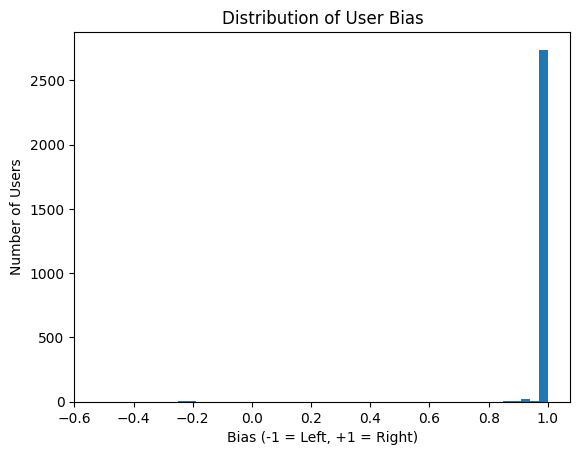

In [26]:
import matplotlib.pyplot as plt

plt.hist(user_counts["user_bias"], bins=50)
plt.title("Distribution of User Bias")
plt.xlabel("Bias (-1 = Left, +1 = Right)")
plt.ylabel("Number of Users")
plt.show()

In [27]:
import numpy as np
# total interactions (only left + right)
user_counts = user_counts.copy()
user_counts["total"] = user_counts["left"] + user_counts["right"]

# avoid division by zero
user_counts = user_counts[user_counts["total"] > 0]

# determine user side
user_counts["leaning"] = user_counts["user_bias"].apply(
    lambda x: "right" if x > 0 else ("left" if x < 0 else "center")
)

# compute cross-cutting exposure
def compute_cross_cutting(row):
    if row["leaning"] == "right":
        return row["left"] / row["total"]
    elif row["leaning"] == "left":
        return row["right"] / row["total"]
    else:
        return np.nan  # or 0, depending on your design

user_counts["cross_cutting"] = user_counts.apply(compute_cross_cutting, axis=1)

In [28]:
user_counts

ideology,author,left,right,user_bias,platform,producer_type,total,leaning,cross_cutting
0,@-2-275,0,42,1.0,YouTube,Youtubers,42,right,0.0
1,@0ironmask027,0,23,1.0,YouTube,Youtubers,23,right,0.0
2,@1.2.3계몽,0,38,1.0,YouTube,Youtubers,38,right,0.0
3,@100백수-h7l,0,22,1.0,YouTube,Youtubers,22,right,0.0
4,@1027kr,0,22,1.0,YouTube,Youtubers,22,right,0.0
...,...,...,...,...,...,...,...,...,...
2786,@희태문,0,21,1.0,YouTube,Youtubers,21,right,0.0
2787,@흰둥이-d4o,0,20,1.0,YouTube,Youtubers,20,right,0.0
2788,@흰소-c7o,0,21,1.0,YouTube,Youtubers,21,right,0.0
2789,@히사메-lk7,0,20,1.0,YouTube,Youtubers,20,right,0.0


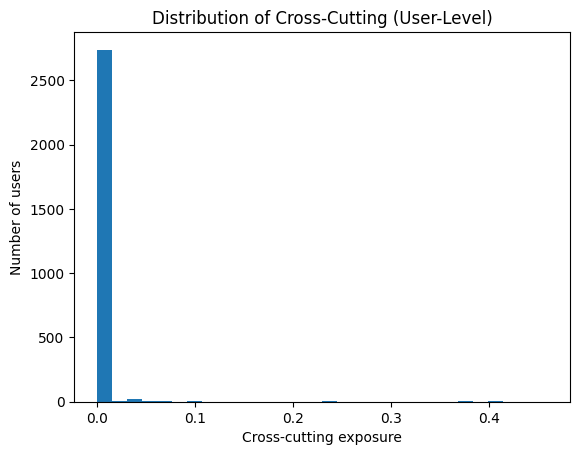

In [29]:
import matplotlib.pyplot as plt

plt.hist(user_counts["cross_cutting"].dropna(), bins=30)

plt.xlabel("Cross-cutting exposure")
plt.ylabel("Number of users")
plt.title("Distribution of Cross-Cutting (User-Level)")

plt.show()

In [30]:
bins = [20, 50, 100, 300, 1000, np.inf]
labels = ["20–49", "50–99", "100–299", "300–999", "1000+"]

user_counts["activity_band"] = pd.cut(
    user_counts["total"],
    bins=bins,
    labels=labels,
    right=False
)

In [31]:
band_summary = (
    user_counts
    .groupby("activity_band")[["user_bias", "cross_cutting"]]
    .mean()
    .reset_index()
)

C:\Users\chldn\AppData\Local\Temp\ipykernel_28788\2619608654.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("activity_band")[["user_bias", "cross_cutting"]]


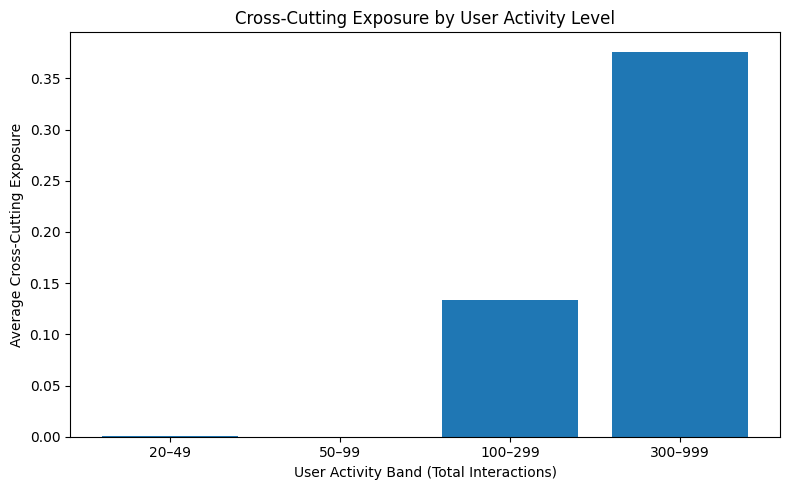

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(band_summary["activity_band"].astype(str),
        band_summary["cross_cutting"])

plt.xlabel("User Activity Band (Total Interactions)")
plt.ylabel("Average Cross-Cutting Exposure")
plt.title("Cross-Cutting Exposure by User Activity Level")

plt.tight_layout()
plt.show()

In [33]:
band_summary = (
    user_counts
    .dropna(subset=["cross_cutting"])
    .groupby("activity_band", observed=True)
    .apply(
        lambda g: np.average(
            g["cross_cutting"],
            weights=g["total"]
        )
    )
    .reset_index(name="weighted_cross_cutting")
)

C:\Users\chldn\AppData\Local\Temp\ipykernel_28788\3072711999.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [34]:
import numpy as np

band_stats = (
    user_counts
    .groupby("activity_band")["cross_cutting"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Standard Error
band_stats["se"] = (
    band_stats["std"] /
    np.sqrt(band_stats["count"])
)

# 95% Confidence Interval
band_stats["ci95"] = 1.96 * band_stats["se"]

print(band_stats)

  activity_band      mean       std  count        se      ci95
0         20–49  0.000918  0.009225   2573  0.000182  0.000356
1         50–99  0.000060  0.000837    193  0.000060  0.000118
2       100–299  0.133803  0.193138     24  0.039424  0.077271
3       300–999  0.376147       NaN      1       NaN       NaN
4         1000+       NaN       NaN      0       NaN       NaN


C:\Users\chldn\AppData\Local\Temp\ipykernel_28788\2513221513.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("activity_band")["cross_cutting"]


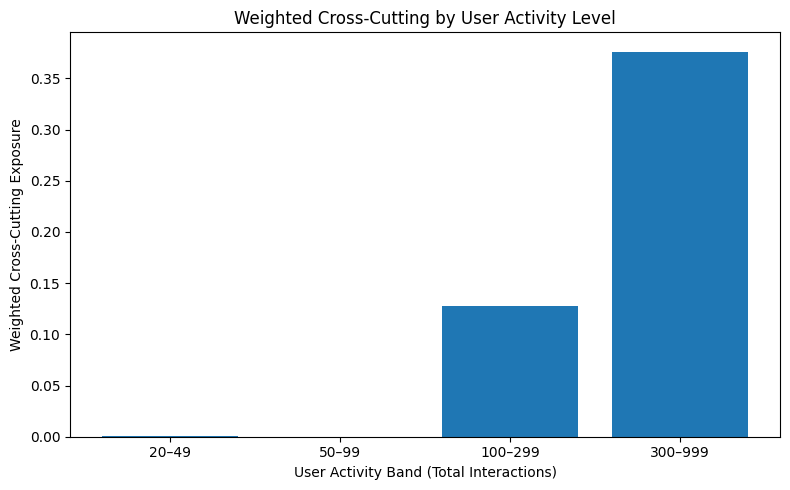

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    band_summary["activity_band"].astype(str),
    band_summary["weighted_cross_cutting"]
)

plt.xlabel("User Activity Band (Total Interactions)")
plt.ylabel("Weighted Cross-Cutting Exposure")
plt.title("Weighted Cross-Cutting by User Activity Level")

plt.tight_layout()
plt.show()

In [ ]:
# unweighted
band_unweighted = (
    user_counts
    .dropna(subset=["cross_cutting"])
    .groupby("activity_band")["cross_cutting"]
    .mean()
    .reset_index(name="unweighted")
)

# merge
band_compare = band_unweighted.merge(
    band_summary,
    on="activity_band"
)

C:\Users\chldn\AppData\Local\Temp\ipykernel_24896\1167140726.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("activity_band")["cross_cutting"]


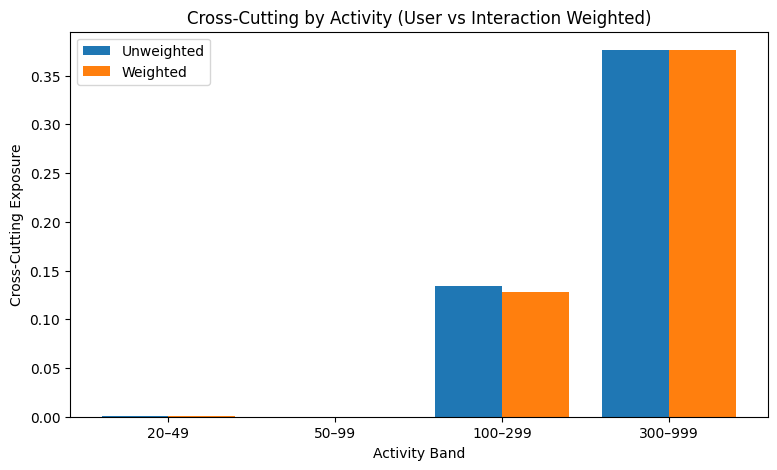

: 

In [ ]:
x = range(len(band_compare))

plt.figure(figsize=(9,5))

plt.bar(x, band_compare["unweighted"], width=0.4, label="Unweighted")
plt.bar([i+0.4 for i in x], band_compare["weighted_cross_cutting"], width=0.4, label="Weighted")

plt.xticks([i+0.2 for i in x], band_compare["activity_band"].astype(str))
plt.xlabel("Activity Band")
plt.ylabel("Cross-Cutting Exposure")
plt.title("Cross-Cutting by Activity (User vs Interaction Weighted)")

plt.legend()
plt.show()